In [2]:
import os
import cv2
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from sklearn.model_selection import train_test_split
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm

In [3]:
# --- Configuration ---
DATA_DIR = "./"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
IMG_SIZE = 224 # Start with 224, can increase to 384 later

# CutMix Config
CUTMIX_PROB = 0.5 # 50% chance to apply CutMix in a batch
BETA = 1.0 # Beta distribution parameter for lambda

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [4]:
# --- Albumentations Data Augmentation ---
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.CLAHE(clip_limit=4.0, p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/Users/netrialiarahmi/Library/Python/3.12/lib/python/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/9z/qsthvdvs1b14z0bd25vy920c0000gn/T/ipykernel_97951/2288798522.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),


In [5]:
# --- Custom Dataset ---
class WasteDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]
            
        label = self.labels[idx]
        return image, label

class_names = sorted(os.listdir(TRAIN_DIR)) 
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

all_image_paths = []
all_labels = []

for cls_name in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    if os.path.isdir(cls_dir):
        for img_name in os.listdir(cls_dir):
            if img_name.endswith((".jpg", ".png", ".jpeg")):
                all_image_paths.append(os.path.join(cls_dir, img_name))
                all_labels.append(class_to_idx[cls_name])

# Train-Validation Split (80/20)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = WasteDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = WasteDataset(val_paths, val_labels, transform=val_transforms)

# Oversampling for Imbalance
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = np.array([class_weights[t] for t in train_labels])
sample_weights = torch.from_numpy(sample_weights).double()
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

/var/folders/9z/qsthvdvs1b14z0bd25vy920c0000gn/T/ipykernel_97951/549219010.py:47: RuntimeWarning: divide by zero encountered in divide
  class_weights = 1. / class_counts


In [6]:
# --- 2. Define Model ---
print("Loading EfficientNetV2-S model...")
weights = models.EfficientNet_V2_S_Weights.DEFAULT
model = models.efficientnet_v2_s(weights=weights)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model = model.to(DEVICE)

# --- 3. Loss & Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Loading EfficientNetV2-S model...


In [7]:
# --- CutMix Helper Function ---
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

In [9]:
# --- 4. Training Loop with CutMix ---
best_val_acc = 0.0
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Determine if we use CutMix in this batch
        r = np.random.rand(1)
        if BETA > 0 and r < CUTMIX_PROB:
            # Generate mixed sample
            lam = np.random.beta(BETA, BETA)
            rand_index = torch.randperm(inputs.size()[0]).to(DEVICE)
            target_a = labels
            target_b = labels[rand_index]
            bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
            
            # Apply CutMix
            inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]
            
            # Adjust lambda to exactly match pixel ratio
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size()[-1] * inputs.size()[-2]))
            
            # Compute output
            outputs = model(inputs)
            
            # Compute Custom CutMix Loss
            loss = criterion(outputs, target_a) * lam + criterion(outputs, target_b) * (1. - lam)
            
            # For accuracy calculation, we take the label with highest ratio
            _, predicted = outputs.max(1)
            train_correct += (lam * predicted.eq(target_a).sum().float() + (1 - lam) * predicted.eq(target_b).sum().float()).item()
            
        else:
            # Normal Training without CutMix
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        train_total += labels.size(0)
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    scheduler.step()
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_cutmix_model.pth")
        print("=> Saved new best CutMix model!")


Epoch 1/30


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Train Loss: 0.4598 | Train Acc: 0.8196
Val Loss: 0.1360 | Val Acc: 0.9525
=> Saved new best CutMix model!

Epoch 2/30


Training:   0%|          | 0/664 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Train Loss: 0.2001 | Train Acc: 0.9050
Val Loss: 0.1004 | Val Acc: 0.9729

Epoch 30/30


Training:   0%|          | 0/664 [00:00<?, ?it/s]

Validation:   0%|          | 0/166 [00:00<?, ?it/s]

Train Loss: 0.1913 | Train Acc: 0.9097
Val Loss: 0.1002 | Val Acc: 0.9721


In [10]:
# --- 5. Inference / Generating Submission ---
print("\nRunning Inference on Test Set...")
model.load_state_dict(torch.load("best_cutmix_model.pth"))
model.eval()

class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.image_files = sorted([f for f in os.listdir(test_dir) if f.endswith(".jpg")], 
                                  key=lambda x: int(os.path.splitext(x)[0]))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_files)
        
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]
            
        return img_name, image

test_dataset = TestDataset(TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

predictions = []
with torch.no_grad():
    for img_names, inputs in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        
        for img_name, pred in zip(img_names, preds):
            img_id = os.path.splitext(img_name)[0]
            predictions.append({"id": img_id, "predicted": pred.item()})
            
submission_df = pd.DataFrame(predictions)
submission_df["id"] = submission_df["id"].astype(int)
submission_df = submission_df.sort_values("id")
submission_df.to_csv("submission_cutmix.csv", index=False)
print("Berhasil menyimpan file submission ke submission_cutmix.csv!")


Running Inference on Test Set...


Testing:   0%|          | 0/46 [00:00<?, ?it/s]

Berhasil menyimpan file submission ke submission_cutmix.csv!


Total salah tebak (Error): 85 gambar


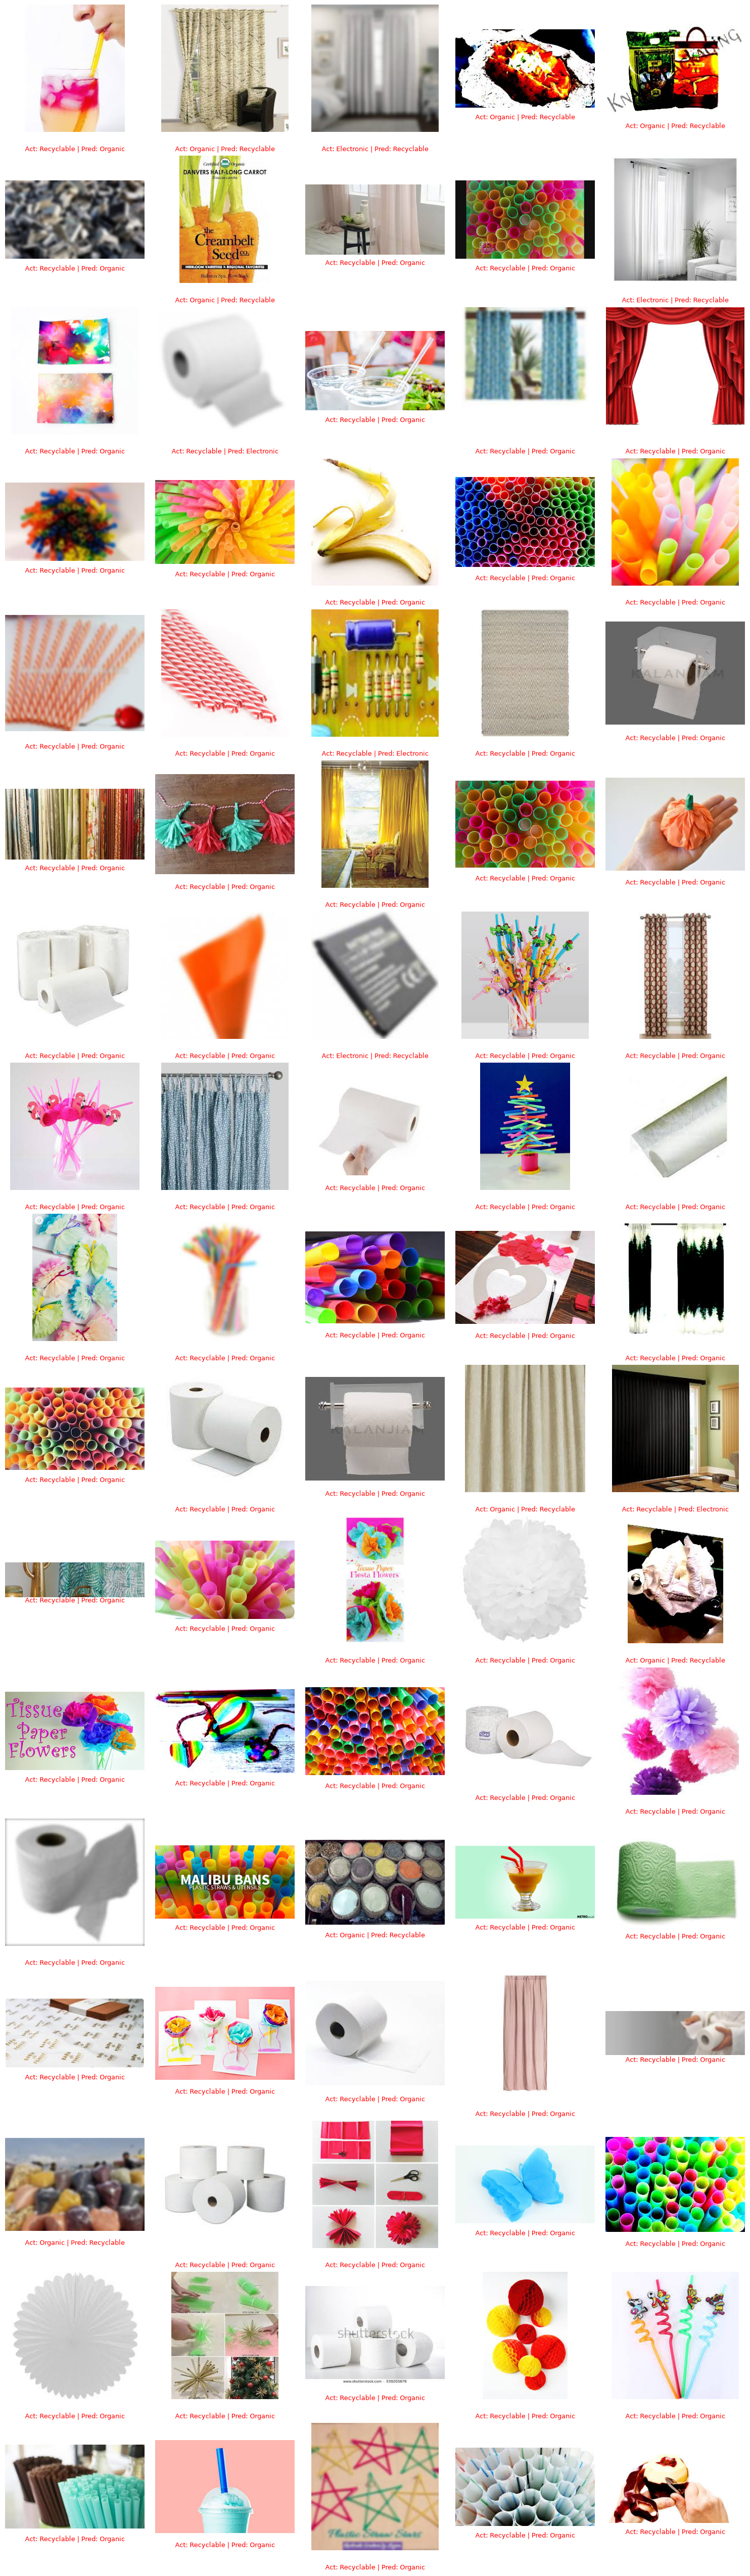

In [11]:
# --- 7. Visualisasi Error di Test Set (CutMix Model) ---
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
from PIL import Image

# Tambahin baris ini biar nggak error!
TEST_DIR = "./test"

# Load Kunci Jawaban & Prediksi (Diubah ke submission_cutmix.csv)
true_df = pd.read_csv("Kunci Jawaban BDC 2026(Kunci Jawaban).csv")
pred_df = pd.read_csv("submission_cutmix.csv")

# Pastikan tipe id sama untuk di-merge
true_df["id"] = true_df["id"].astype(int)
pred_df["id"] = pred_df["id"].astype(int)

# FIX MAC .DS_Store BUG (Koreksi geser indeks)
if pred_df["predicted"].max() == 3:
    pred_df["predicted"] = pred_df["predicted"] - 1

# Gabungkan data
df = pd.merge(true_df, pred_df, on="id")

# Buat nama file gambar
df["filename"] = df["id"].astype(str) + ".jpg"

# Cari yang salah
salah_df = df[df["Code"] != df["predicted"]]
print(f"Total salah tebak (Error): {len(salah_df)} gambar")

# Mapping label
label_map = {0: "Recyclable", 1: "Electronic", 2: "Organic"}

# Tampilkan SEMUA gambar yang salah
num_show = len(salah_df)
if num_show > 0:
    # Bikin grid dinamis (5 kolom, baris menyesuaikan jumlah error)
    cols = 5
    rows = math.ceil(num_show / cols)
    
    # Tinggi gambar (figsize) kita sesuaikan jumlah baris biar nggak numpuk
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    
    # PERBAIKAN: Handle kasus kalau error-nya cuma sebaris
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows > 1 or cols > 1:
        axes = axes.flatten()
    
    for i, (_, row) in enumerate(salah_df.iterrows()):
        # TEST_DIR udah didefinisiin di atas
        img_path = os.path.join(TEST_DIR, row["filename"])
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[i].imshow(img)
            
            actual_name = label_map.get(row["Code"], str(row["Code"]))
            pred_name = label_map.get(row["predicted"], str(row["predicted"]))
            
            # Letakkan teks di BAWAH gambar, ukuran kecil
            axes[i].set_title("") 
            axes[i].text(0.5, -0.15, f"Act: {actual_name} | Pred: {pred_name}", 
                         fontsize=9, color="red", ha="center", transform=axes[i].transAxes)
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, "Image Not Found", ha="center", va="center")
            axes[i].axis("off")
            
    # Sembunyikan plot kosong kalau ada sisa di baris terakhir
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
        
    plt.tight_layout()
    plt.show()
else:
    print("Hebat! Tidak ada gambar yang salah.")
